In [91]:
from langgraph.graph import StateGraph
from IPython.display import Image, display
from neo4j import GraphDatabase
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal
from collections import deque
from langchain_ollama import ChatOllama
from ollama import Client 
from langgraph.checkpoint.memory import MemorySaver 

NEO4J_URI=neo4j+s://YOUR_INSTANCE.databases.neo4j.io
NEO4J_USERNAME=neo4j
NEO4J_PASSWORD=YOUR_PASSWORD
NEO4J_DATABASE=neo4j
AURA_INSTANCEID=YOUR_INSTANCEID
AURA_INSTANCENAME=Instance01


In [92]:

class GraphDB:
    def __init__(self, url, user, password):
        self.driver=GraphDatabase.driver(url, auth=(user, password))
        print("The Graph Database has been started.")

    def close(self):
        self.driver.close()
        print("\nDriver Closed.")

    def run_query(self, query, params={}):
        with self.driver.session() as session:
            result = session.run(query, params)
            return [record.data() for record in result]

In [93]:
database_description="""
    The database consists of three distinct nodes, each defined by a unique label (:TypeA, :TypeB, and :TypeC). 
    These nodes are connected by "TO" relationships. 
"""

In [99]:
class agent_state(TypedDict):
    login_url:str
    login_password:str
    login_user:str

    status:str
    repairs:str
    query:str
    results:list
    
    

In [100]:
def generate_repairs(state:agent_state):
    query=state["query"]
    
    formatted_inconsistency=describe_query(query)
    repairs=""
    client = Client(
    host="https://ollama.com",
    headers={'Authorization': 'Bearer <OLLAMA_BEARER_TOKEN>'})
    fquestion=f"""
    {database_description}
    The database has inconsistencies that we want to remove.
    One such inconsistency is{formatted_inconsistency}.
    You can delete  an edge,a node ,replace a edge or replace a node.But only one change.
    Please generate all possible queries that could fix this.
    IMP:When generating the query also remember to use the description to retrieve the pattern then remove the inconsisteny.
    Return only the cypher queries.For now only one.
    Make sure it is in proper format with a semi-colon denoting the end.
    (Generate the cypher queries only.)
    """

    messages=[
        { 
            "role":"user",
            "content":fquestion
        },]

    print("The Generated Query for repair:\n")
    for part in client.chat('kimi-k2:1t-cloud', messages=messages, stream=True):
        #print(part['message']['content'], end='', flush=True)
        repairs=repairs+part['message']['content']


    # counter=0
    # repair=""
    # for i in repairs:
    #     if(i=='\n' and counter==0):
    #         counter=counter+1
    #     if(counter==1 and i!='\''):
    #         repair=repair+i
        

    print(repairs)
    repairs=query_is_correct(repairs)
    return {"repairs":repairs}



def retrieve(state:agent_state):
    curr_query=state["query"]
    print(curr_query)
    
    NEO4J_URL=state["login_url"]
    NEO4J_PASSWORD=state["login_password"]
    NEO4J_USER=state["login_user"]

    db = GraphDB(NEO4J_URL, NEO4J_USER, NEO4J_PASSWORD)
    result = db.run_query(curr_query)
    db.close()

    return {"result":result}




def describe_query(query):
   
    client = Client(
    host="https://ollama.com",
    headers={'Authorization': 'Bearer <OLLAMA_BEARER_TOKEN>'})

    print("The Description of the Input:")
    fquestion=f"""
    {database_description}
    Describe this query:{query} in detail,make a short paragraph.
    Return only the paragraph.
    """
    messages=[
        { 
            "role":"user",
            "content":fquestion
        },]

    for part in client.chat('kimi-k2:1t-cloud', messages=messages, stream=True):
        print(part['message']['content'], end='', flush=True)
    
    return query 
    

def apply(state:agent_state):
    curr_query=state["repairs"]
    NEO4J_URL=state["login_url"]
    NEO4J_PASSWORD=state["login_password"]
    NEO4J_USER=state["login_user"]

    db = GraphDB(NEO4J_URL, NEO4J_USER, NEO4J_PASSWORD)
    result = db.run_query(curr_query)
    db.close()



def query_is_correct(string):
    #replace the the '\n' with a space and remove any prior character generated by the LLMs
    flag=False
    corrected_string=""
    for ch in string:
        if(ch=='M'):
            flag=True

        if(flag):
            if(ch=='\n'):
                corrected_string=corrected_string+" "
            else:
                corrected_string=corrected_string+ch
        if(ch==';' or ch=='\''):
            break
        
    print(corrected_string)
    return corrected_string
            



def manager(state:agent_state):
    message=input("Enter a query to process or EXIT for exiting the process:")
    
    if(message=="EXIT"):
        return {"status":"EXIT"}
    else:
        return {"status":"Processing","query":message}


def check2(state:agent_state)->Literal["manager","generate_repairs"]:

    if(len(result)==0):
        print("No such patterns in the knowledge graph.")
        return "manager"

    else:
        return "generate_repairs"


def check3(state:agent_state)->Literal["manager","generate_repairs"]:
    
    db = GraphDB(NEO4J_URL, NEO4J_USER, NEO4J_PASSWORD)
    result = db.run_query(state["query"])
    db.close()
    if(len(result)==0):
        print("Repairs were done.")
        return "manager"

    else:
        return "generate_repairs"

def check1(state:agent_state)->Literal[END,"retrieve"]:
    status=state["status"]
    if(status=="EXIT"):
        print("You have exited the process.")
        return END

    else:
        return "retrieve"

In [101]:
workflow=StateGraph(agent_state)
workflow.add_node("retrieve", retrieve)
workflow.add_node("generate_repairs",generate_repairs)
workflow.add_node("apply",apply)
workflow.add_node("manager",manager)


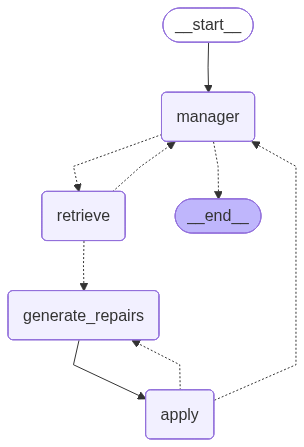

In [102]:
workflow.add_edge(START, "manager")
workflow.add_conditional_edges("manager", check1)
workflow.add_conditional_edges("retrieve", check2)
workflow.add_edge("retrieve", "generate_repairs")
workflow.add_edge("generate_repairs", "apply")
workflow.add_conditional_edges("apply", check3)

chain = workflow.compile()

# Show workflo
display(Image(chain.get_graph().draw_mermaid_png()))

In [103]:
query="""MATCH (a:TypeA),(b:TypeB),(c:TypeC),(a)-[r1:TO]->(b),(b)-[r2:TO]->(c),(a)-[r3:TO]->(c) RETURN a,b,c,r1,r2,r3;"""
status="Processing"
index=0
NEO4J_URL="neo4j+s://YOUR_INSTANCE.databases.neo4j.io"
NEO4J_USER="neo4j"
NEO4J_PASSWORD="<NEO4J_PASSWORD>"


chain.invoke({"login_url":NEO4J_URL,"login_password":NEO4J_PASSWORD,"login_user":NEO4J_USER,"status":status})


Enter a query to process or EXIT for exiting the process: MATCH (a:TypeA),(b:TypeB),(c:TypeC),(a)-[r1:TO]->(b),(b)-[r2:TO]->(c),(a)-[r3:TO]->(c) RETURN a,b,c,r1,r2,r3;


MATCH (a:TypeA),(b:TypeB),(c:TypeC),(a)-[r1:TO]->(b),(b)-[r2:TO]->(c),(a)-[r3:TO]->(c) RETURN a,b,c,r1,r2,r3;
The Graph Database has been started.

Driver Closed.
The Description of the Input:
The query finds all triples in which a TypeA node is linked by a TO relationship to a TypeB node, that same TypeB node is linked by another TO relationship to a TypeC node, and, crucially, the original TypeA node is also directly linked by a third TO relationship to that same TypeC node; it then returns the three nodes and the three relationships that form this triangular pattern.The Generated Query for repair:

```cypher
MATCH (a:TypeA)-[r3:TO]->(c:TypeC)
WHERE (a)-[:TO]->(:TypeB)-[:TO]->(c)
DELETE r3;
```
MATCH (a:TypeA)-[r3:TO]->(c:TypeC) WHERE (a)-[:TO]->(:TypeB)-[:TO]->(c) DELETE r3;
The Graph Database has been started.

Driver Closed.
The Graph Database has been started.

Driver Closed.
Repairs were done.


Enter a query to process or EXIT for exiting the process: MATCH (a:TypeA),(b:TypeB),(c:TypeC),(a)-[r1:TO]->(b),(b)-[r2:TO]->(a) RETURN a,b,r1,r2;


MATCH (a:TypeA),(b:TypeB),(c:TypeC),(a)-[r1:TO]->(b),(b)-[r2:TO]->(a) RETURN a,b,r1,r2;
The Graph Database has been started.

Driver Closed.
The Description of the Input:
The query searches for any :TypeA node (a), any :TypeB node (b), and any :TypeC node (c), then insists that a and b are linked by a pair of opposite TO relationships—one from a to b (r1) and another from b back to a (r2). It returns the two nodes (a and b) along with both relationships, effectively isolating every mutual TO pairing between TypeA and TypeB while simply mentioning TypeC without using it in the pattern.The Generated Query for repair:

MATCH (a:TypeA)-[r:TO]->(b:TypeB)-[:TO]->(a)  
DELETE r;
MATCH (a:TypeA)-[r:TO]->(b:TypeB)-[:TO]->(a)   DELETE r;
The Graph Database has been started.

Driver Closed.
The Graph Database has been started.

Driver Closed.
Repairs were done.


Enter a query to process or EXIT for exiting the process: EXIT


You have exited the process.


{'login_url': 'neo4j+s://YOUR_INSTANCE.databases.neo4j.io',
 'login_password': '<NEO4J_PASSWORD>',
 'login_user': 'neo4j',
 'status': 'EXIT',
 'repairs': 'MATCH (a:TypeA)-[r:TO]->(b:TypeB)-[:TO]->(a)   DELETE r;',
 'query': 'MATCH (a:TypeA),(b:TypeB),(c:TypeC),(a)-[r1:TO]->(b),(b)-[r2:TO]->(a) RETURN a,b,r1,r2;'}